Random_state:  33
              precision    recall  f1-score   support

        Heal       0.90      1.00      0.95         9
         Not       1.00      0.86      0.92         7

    accuracy                           0.94        16
   macro avg       0.95      0.93      0.94        16
weighted avg       0.94      0.94      0.94        16

Accuracy: 93.75 %


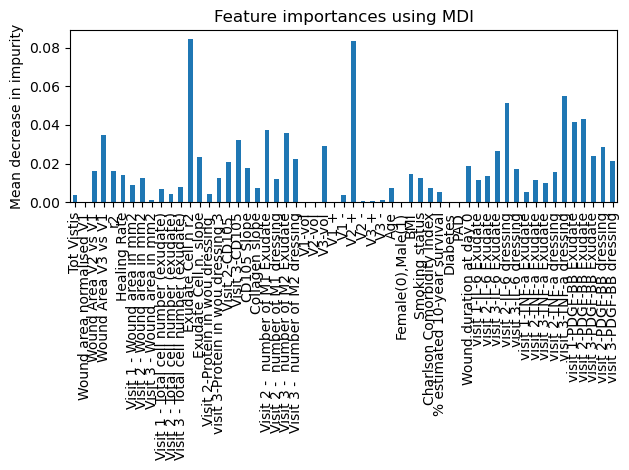

[[ 0.6304586   0.36954138]
 [ 0.28943712  0.7105629 ]
 [ 0.62551844  0.37448153]
 [ 0.78728867  0.21271133]
 [ 0.3759839   0.6240161 ]
 [ 0.7951404   0.2048596 ]
 [ 0.7177701   0.28222993]
 [ 0.546988    0.45301196]
 [ 0.38181263  0.61818737]
 [ 1.0275031  -0.0275031 ]
 [ 0.54680115  0.45319885]
 [ 0.39403498  0.605965  ]
 [ 0.6460521   0.3539479 ]
 [ 0.3125437   0.6874563 ]
 [ 0.66307986  0.33692014]
 [ 0.32950002  0.6705    ]]


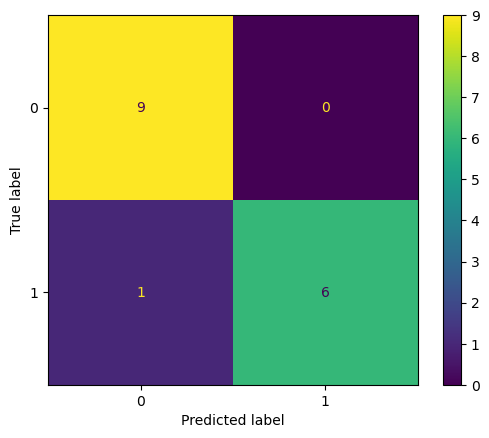

<Figure size 40000x12000 with 0 Axes>

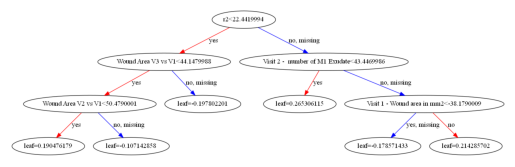

              precision    recall  f1-score   support

        Heal       1.00      1.00      1.00        36
         Not       1.00      1.00      1.00        27

    accuracy                           1.00        63
   macro avg       1.00      1.00      1.00        63
weighted avg       1.00      1.00      1.00        63

--------------------------------------------------------------------------------------------------


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn import tree
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas as pd
import re
import random
from tensorflow.keras.utils import to_categorical
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
import xgboost as xgb
from xgboost import plot_tree
from xgboost import XGBClassifier
from dtreeviz import model




Treatment=pd.read_csv("../AD report/Test_change_train.csv")
Treatment_test=pd.read_csv("../AD report/Test_change_test.csv")


X_train=Treatment.iloc[:,1:]
y_train=Treatment.iloc[:,0]

X_test=Treatment_test.iloc[:,1:]
y_test=Treatment_test.iloc[:,0]



#y_train = to_categorical(y_train)
#y_test = to_categorical(y_test)




R_state=random.randrange(1,100)
print("Random_state: ",R_state)
#R_state=45


clf=XGBClassifier(booster="dart",
                  normalize_type="tree",
                  tree_method="approx",
                    objective="reg:squarederror",
                  eta=0.5,
                 # max_depth=4,
                  subsample=0.6,
                  colsample_bytree=0.8,
                 # colsample_bylevel=0.9,
                 #colsample_bynode=0.7,
                  #reg_lambda=0.6,
                  #reg_alpha=0.7,
                  rate_drop=1,
                  skip_drop=0.6,
                  one_drop=1,
                    random_state=R_state,
                  max_bin=2056,
                #num_parallel_tree=25,
  
                  sample_type="weighted",
                
                  
                  
                  
    )

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test, iteration_range=(0, 50))
y_pred = (y_pred > 0.5) 


class_names=["Heal","Not"]

print(classification_report(y_test,y_pred,output_dict=False,target_names=class_names))


accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", (accuracy*100),"%")

names=clf.get_booster().feature_names
importances = clf.feature_importances_

forest_importances = pd.Series(importances, index=names)
#forest_importances = pd.Series(importances)

fig, ax = plt.subplots()
forest_importances.plot.bar( ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()
plt.show()

f = open("out.txt", "w")
var=clf.get_booster().get_dump()
for line in var:
    f.write(f"{line}\n")
f.close()

print(clf.predict_proba(X_test))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

plt.figure(figsize=(400, 120))
plot_tree(clf, num_trees=W_tree)
plt.show()

y_pred = clf.predict(X_train)
y_pred = (y_pred > 0.5) 
print(classification_report(y_train,y_pred,output_dict=False,target_names=class_names))

print("--------------------------------------------------------------------------------------------------")

target = 'key'



from supertree import SuperTree
st = SuperTree(
    clf, 
    X_test, 
    y_test, 
    names, 
    class_names
)
# Visualize the tree
st.show_tree(which_tree=W_tree)